In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("/content/drive/MyDrive/visa_estimator_cleaned.csv")
df.head()


Mounted at /content/drive


,education_level,experience_years,annual_salary_usd,company_size,age,country_score,job_skill_score,previous_visas,application_score,visa_approval_score
0,4,15,52939,1196,42,0.501252,0.313991,5,0.588091,100.0
1,5,13,80601,5168,39,0.902772,0.994638,1,0.896613,100.0
2,3,9,48101,7874,21,0.925827,0.644535,4,0.925796,100.0
3,5,6,92710,9932,51,0.724348,0.633114,1,0.605607,100.0
4,5,12,41514,4099,54,0.546535,0.734640,4,0.856800,100.0


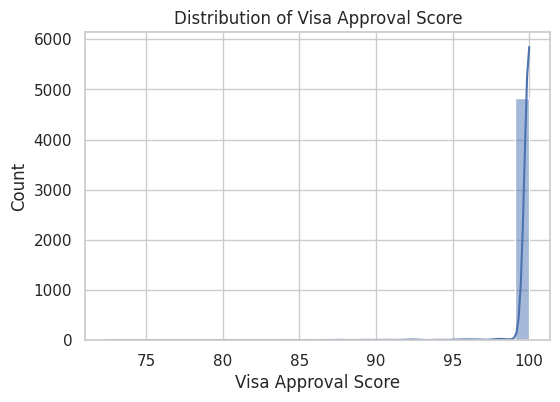

In [2]:
plt.figure(figsize=(6,4))
sns.histplot(df["visa_approval_score"], bins=30, kde=True)
plt.title("Distribution of Visa Approval Score")
plt.xlabel("Visa Approval Score")
plt.show()


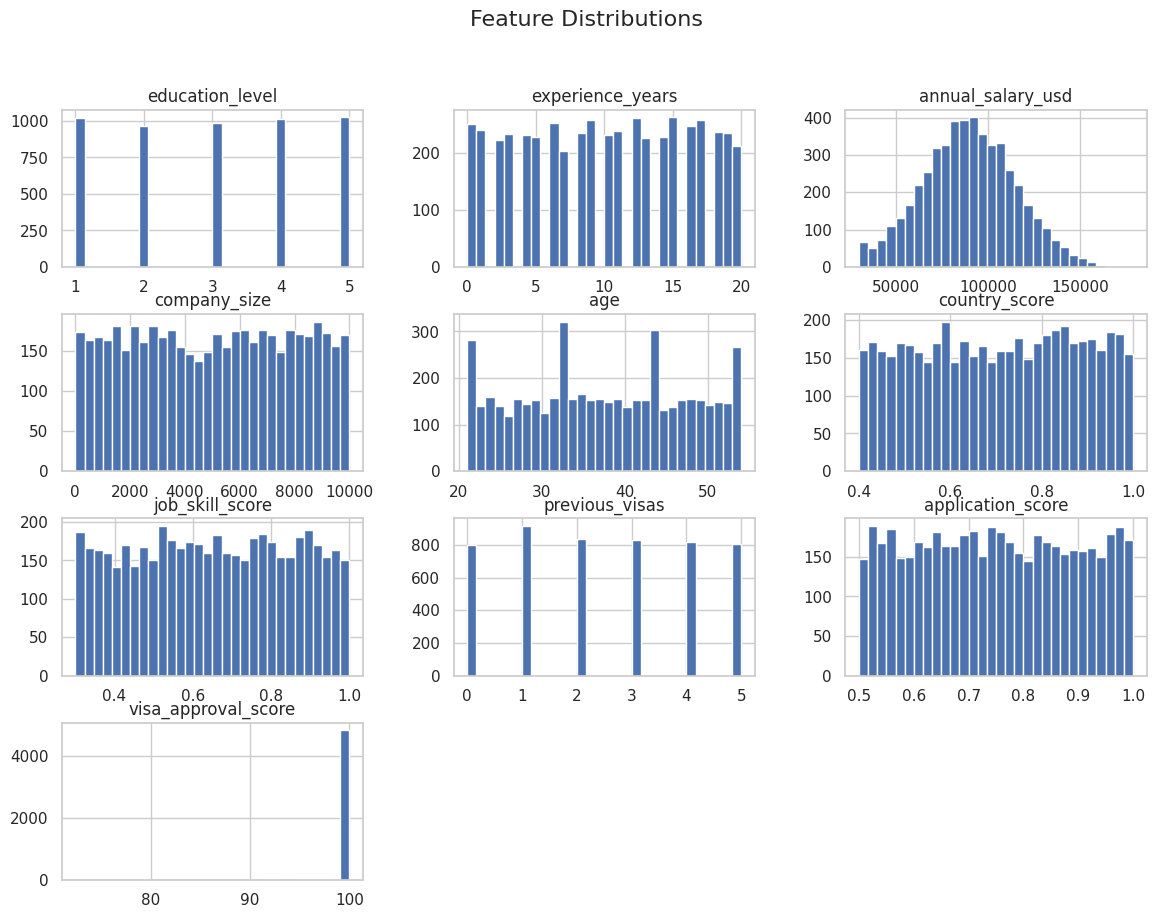

In [3]:
df.hist(figsize=(14,10), bins=30)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()


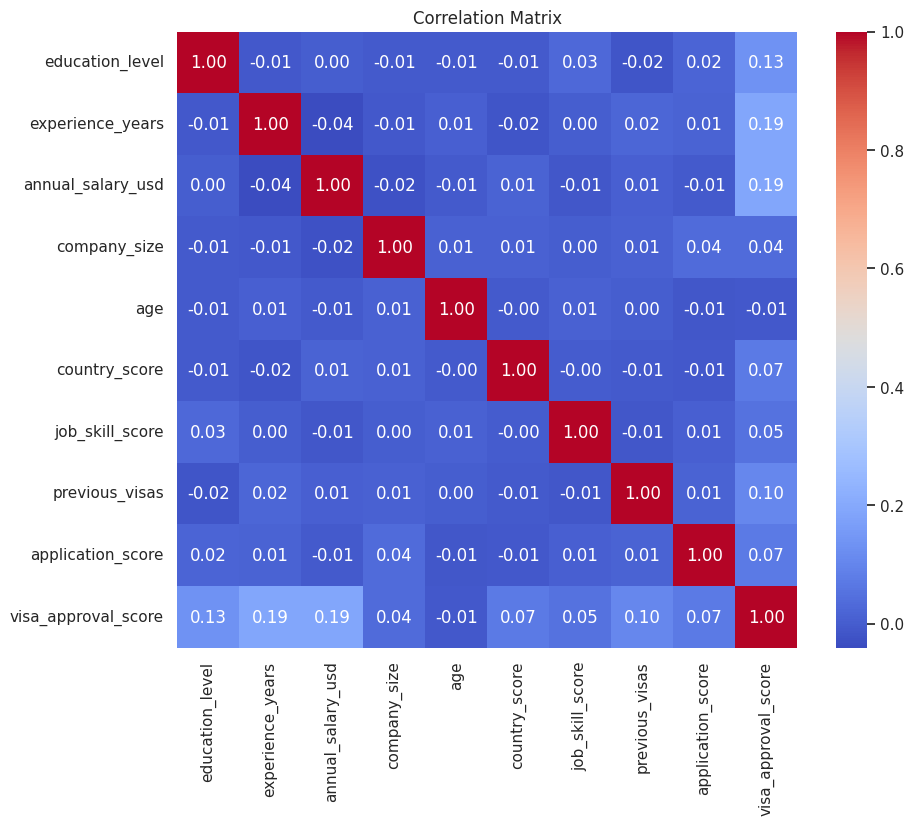

In [5]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


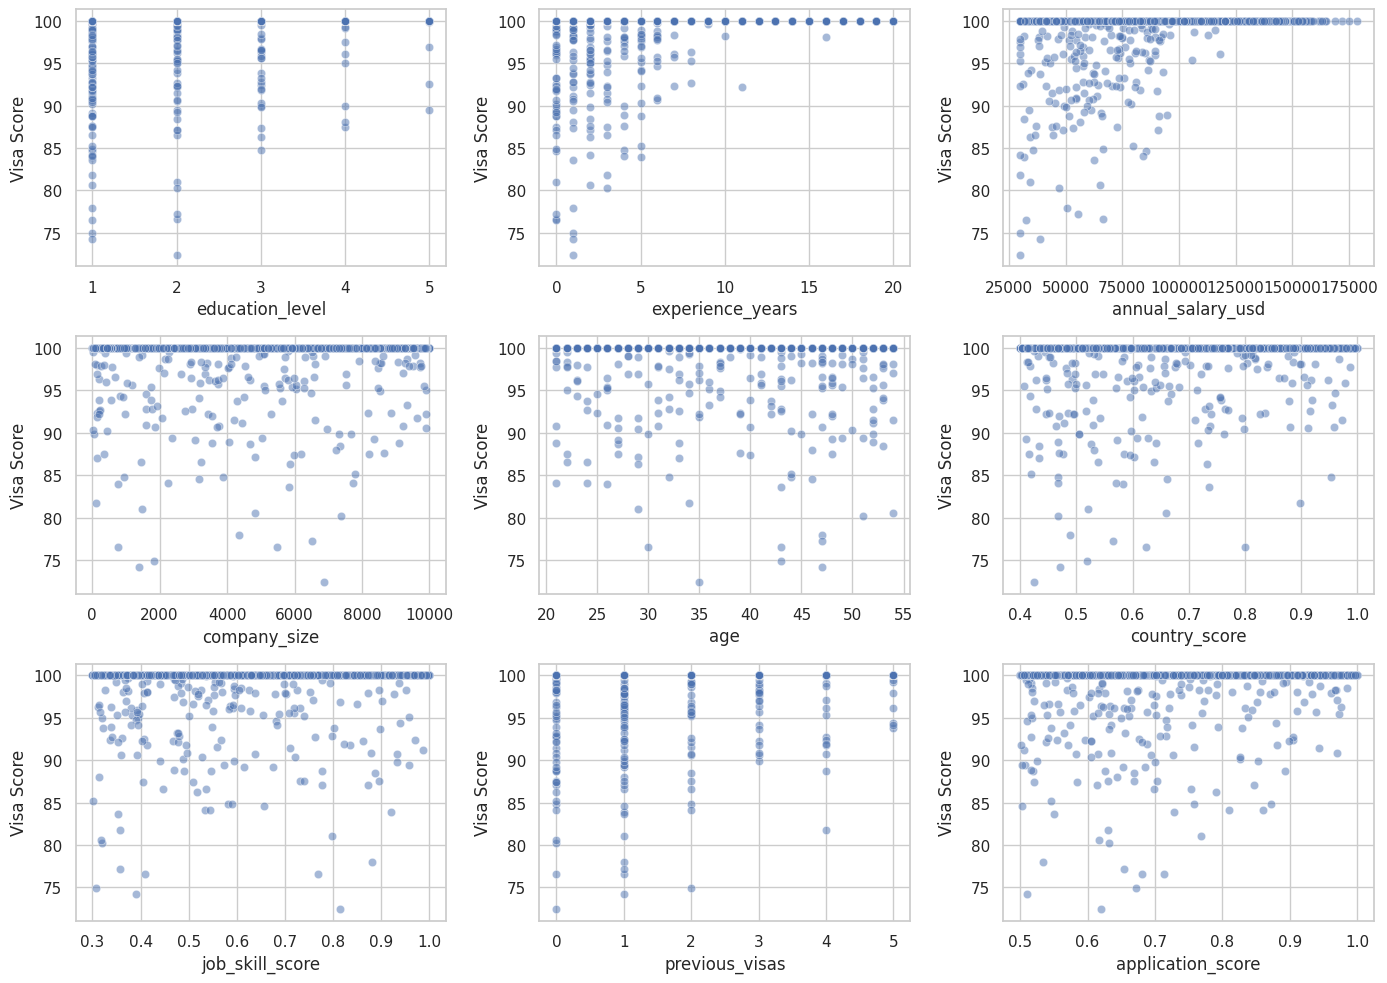

In [6]:
features = df.columns.drop("visa_approval_score")

plt.figure(figsize=(14,10))
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.scatterplot(x=df[col], y=df["visa_approval_score"], alpha=0.5)
    plt.xlabel(col)
    plt.ylabel("Visa Score")

plt.tight_layout()
plt.show()


In [7]:
np.random.seed(42)
df["season_index"] = np.random.randint(1, 5, size=len(df))


In [8]:
df["experience_band"] = pd.cut(
    df["experience_years"],
    bins=[-1, 2, 5, 10, 20],
    labels=[1, 2, 3, 4]
)
df["experience_band"] = df["experience_band"].astype(int)


In [9]:
df["salary_per_experience"] = df["annual_salary_usd"] / (df["experience_years"] + 1)


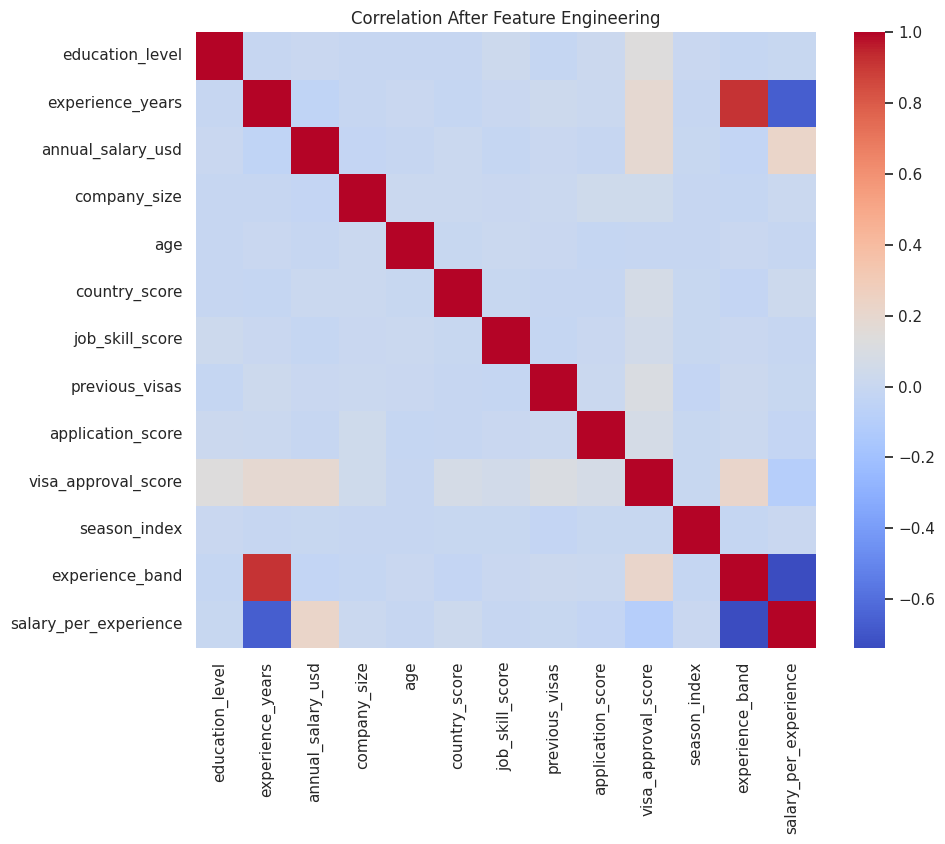

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation After Feature Engineering")
plt.show()


In [11]:
fe_path = "/content/drive/MyDrive/visa_estimator_feature_engineered.csv"
df.to_csv(fe_path, index=False)

fe_path


'/content/drive/MyDrive/visa_estimator_feature_engineered.csv'